<a href="https://colab.research.google.com/github/YYYingZZZ/SAD_2023/blob/main/CourseTrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import files
import pandas as pd


uploaded = files.upload()
filename = list(uploaded.keys())[0]

#with open(filename, 'r') as f:
    #for i in range(5):
        #print(f.readline().strip())

columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

df = pd.read_csv(filename, header=None, names=columns)
print(df.head())
df.to_csv('car.csv', index=False, encoding='utf-8-sig')
#files.download('car.csv')

Saving car.txt to car (1).txt
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [24]:
df = pd.DataFrame(df)
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [25]:
import numpy as np

x = df.drop('class', axis=1)
y = df['class']
x = pd.get_dummies(x)
print('Class labels:', np.unique(y))

Class labels: ['acc' 'good' 'unacc' 'vgood']


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1, stratify=y)

In [27]:
X_train

,buying_high,buying_low,buying_med,buying_vhigh,maint_high,maint_low,maint_med,maint_vhigh,doors_2,doors_3,...,doors_5more,persons_2,persons_4,persons_more,lug_boot_big,lug_boot_med,lug_boot_small,safety_high,safety_low,safety_med
639,True,False,False,False,True,False,False,False,False,False,...,True,False,False,True,False,False,True,False,True,False
1400,False,True,False,False,False,False,False,True,False,False,...,True,False,False,True,False,True,False,True,False,False
1034,False,False,True,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
283,False,False,False,True,False,False,True,False,False,False,...,False,False,True,False,False,True,False,False,False,True
1145,False,False,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,False,True,False,False,False,False,True,False,False,False,...,False,False,True,False,False,True,False,False,False,True
88,False,False,False,True,False,False,False,True,False,False,...,True,True,False,False,True,False,False,False,False,True
907,False,False,True,False,False,False,False,True,False,True,...,False,False,True,False,True,False,False,False,False,True
777,True,False,False,False,False,True,False,False,True,False,...,False,False,False,True,False,True,False,False,True,False


In [28]:
print('Labels counts in y:')
print(y.value_counts())

print('Labels counts in y_train:')
print(y_train.value_counts())

print('Labels counts in y_test:')
print(y_test.value_counts())

Labels counts in y:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64
Labels counts in y_train:
class
unacc    847
acc      269
good      48
vgood     45
Name: count, dtype: int64
Labels counts in y_test:
class
unacc    363
acc      115
good      21
vgood     20
Name: count, dtype: int64


In [29]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)

StandardScaler()

In [30]:
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [31]:
X_train_std

array([[ 1.67031993, -0.57830536, -0.5604734 , ..., -0.6861508 ,
         1.37562513, -0.70842315],
       [-0.5986877 ,  1.72919028, -0.5604734 , ...,  1.45740557,
        -0.72694223, -0.70842315],
       [-0.5986877 , -0.57830536,  1.78420599, ...,  1.45740557,
        -0.72694223, -0.70842315],
       ...,
       [-0.5986877 , -0.57830536,  1.78420599, ..., -0.6861508 ,
        -0.72694223,  1.41158572],
       [ 1.67031993, -0.57830536, -0.5604734 , ..., -0.6861508 ,
         1.37562513, -0.70842315],
       [-0.5986877 ,  1.72919028, -0.5604734 , ...,  1.45740557,
        -0.72694223, -0.70842315]])

In [32]:
sc.mean_

array([0.26385443, 0.25062035, 0.23904053, 0.2464847 , 0.24483044,
       0.26137304, 0.24069479, 0.25310174, 0.25310174, 0.25723739,
       0.23242349, 0.25723739, 0.32340778, 0.33664185, 0.33995037,
       0.32588916, 0.32919768, 0.34491315, 0.32009926, 0.34574028,
       0.33416046])

In [33]:
sc.scale_

array([0.4407213 , 0.43337027, 0.42649754, 0.43096403, 0.42998662,
       0.43938272, 0.42750533, 0.43478874, 0.43478874, 0.43711133,
       0.42237757, 0.43711133, 0.46777686, 0.47256123, 0.47369201,
       0.46870611, 0.46992188, 0.47533995, 0.46651444, 0.47560902,
       0.47169614])

In [34]:
from sklearn.linear_model import Perceptron

ppn = Perceptron(eta0=0.1,random_state=1)
ppn.fit(X_train_std,y_train)

Perceptron(eta0=0.1, random_state=1)

In [35]:
y_pred = ppn.predict(X_test_std)

In [36]:
from sklearn.metrics import accuracy_score
print('Accuracy: %.3f' % accuracy_score(y_test,y_pred))
#print('Misclassified samples: %d' % (y_test != y_pred).sum())

Accuracy: 0.855


In [37]:
print('Accuracy: %.3f' % ppn.score(X_test_std, y_test))

Accuracy: 0.855


In [38]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

In [39]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=100.0, solver= 'lbfgs', multi_class= 'ovr', random_state=1)
lr.fit(X_train_std, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=100.0, multi_class='ovr', random_state=1)

In [40]:
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [41]:
models = {
    'Perceptron': {
        'model': Perceptron(random_state=42),
        'use_scaler': True
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=5000, random_state=42),
        'use_scaler': True
    },
    'Support Vector Machine': {
        'model': SVC(kernel='rbf'),
        'use_scaler': True
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'use_scaler': False
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(n_neighbors=5),
        'use_scaler': True
    }
}

In [42]:
results = []
labels_order = ['unacc', 'acc', 'good', 'vgood']

def evaluate_model(model_name, model, use_scaler=True):
    steps = [
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]

    if use_scaler:
        steps.append(('scaler', StandardScaler(with_mean=False)))

    steps.append(('classifier', model))

    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=labels_order)
    cm_df = pd.DataFrame(cm, index=labels_order, columns=labels_order)

    report_text = classification_report(
        y_test, y_pred,
        labels=labels_order,
        zero_division=0
    )

    report_dict = classification_report(
        y_test, y_pred,
        labels=labels_order,
        output_dict=True,
        zero_division=0
    )

    results.append({
        'Model': model_name,
        'Precision': report_dict['weighted avg']['precision'],
        'Recall': report_dict['weighted avg']['recall'],
        'F1-score': report_dict['weighted avg']['f1-score']
    })

    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")

    print("\nConfusion Matrix:")
    print(cm_df)

    print("\nClassification Report:")
    print(report_text)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
    disp.plot(values_format='d')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    return pipeline


Model: Perceptron

Confusion Matrix:
       unacc  acc  good  vgood
unacc    339   23     1      0
acc        9   96     8      2
good       0   10    11      0
vgood      0    6     0     14

Classification Report:
              precision    recall  f1-score   support

       unacc       0.97      0.93      0.95       363
         acc       0.71      0.83      0.77       115
        good       0.55      0.52      0.54        21
       vgood       0.88      0.70      0.78        20

    accuracy                           0.89       519
   macro avg       0.78      0.75      0.76       519
weighted avg       0.89      0.89      0.89       519



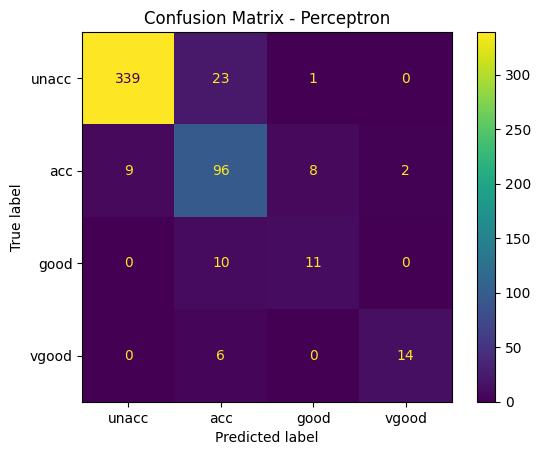


Model: Logistic Regression

Confusion Matrix:
       unacc  acc  good  vgood
unacc    352   11     0      0
acc       13  101     0      1
good       0    2    17      2
vgood      0    2     0     18

Classification Report:
              precision    recall  f1-score   support

       unacc       0.96      0.97      0.97       363
         acc       0.87      0.88      0.87       115
        good       1.00      0.81      0.89        21
       vgood       0.86      0.90      0.88        20

    accuracy                           0.94       519
   macro avg       0.92      0.89      0.90       519
weighted avg       0.94      0.94      0.94       519



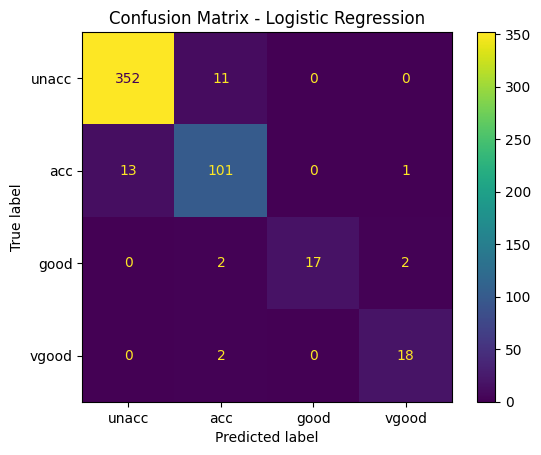


Model: Support Vector Machine

Confusion Matrix:
       unacc  acc  good  vgood
unacc    359    4     0      0
acc        1  112     0      2
good       0    0    19      2
vgood      0    4     0     16

Classification Report:
              precision    recall  f1-score   support

       unacc       1.00      0.99      0.99       363
         acc       0.93      0.97      0.95       115
        good       1.00      0.90      0.95        21
       vgood       0.80      0.80      0.80        20

    accuracy                           0.97       519
   macro avg       0.93      0.92      0.92       519
weighted avg       0.98      0.97      0.98       519



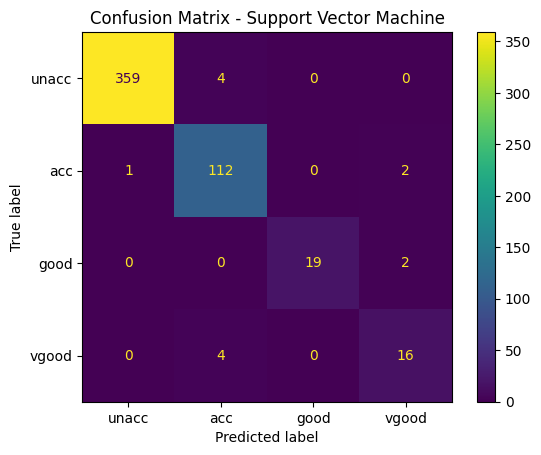


Model: Decision Tree

Confusion Matrix:
       unacc  acc  good  vgood
unacc    362    1     0      0
acc        3  110     0      2
good       0    1    18      2
vgood      0    2     1     17

Classification Report:
              precision    recall  f1-score   support

       unacc       0.99      1.00      0.99       363
         acc       0.96      0.96      0.96       115
        good       0.95      0.86      0.90        21
       vgood       0.81      0.85      0.83        20

    accuracy                           0.98       519
   macro avg       0.93      0.92      0.92       519
weighted avg       0.98      0.98      0.98       519



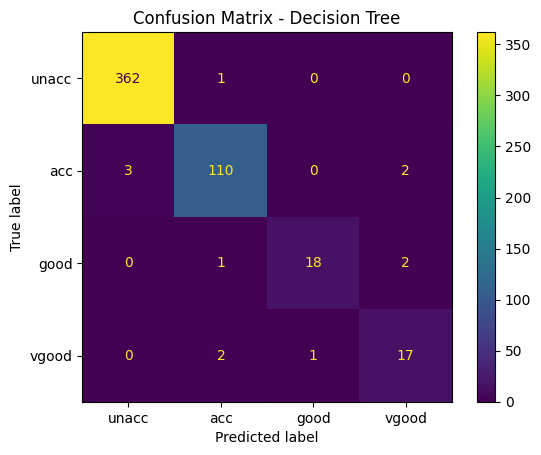


Model: K-Nearest Neighbors

Confusion Matrix:
       unacc  acc  good  vgood
unacc    354    9     0      0
acc       34   76     3      2
good       5   12     3      1
vgood      6    6     6      2

Classification Report:
              precision    recall  f1-score   support

       unacc       0.89      0.98      0.93       363
         acc       0.74      0.66      0.70       115
        good       0.25      0.14      0.18        21
       vgood       0.40      0.10      0.16        20

    accuracy                           0.84       519
   macro avg       0.57      0.47      0.49       519
weighted avg       0.81      0.84      0.82       519



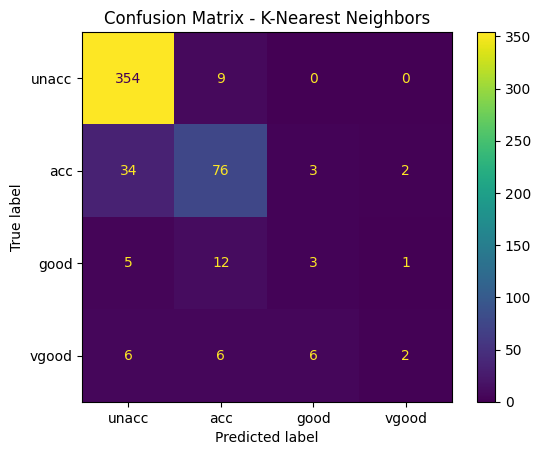

In [43]:
trained_models = {}

for model_name, model_info in models.items():
    trained_models[model_name] = evaluate_model(
        model_name,
        model_info['model'],
        model_info['use_scaler']
    )

In [44]:
results_df = pd.DataFrame(results).sort_values(by='F1-score', ascending=False)
print(results_df)

                    Model  Precision    Recall  F1-score
3           Decision Tree   0.977007  0.976879  0.976823
2  Support Vector Machine   0.975578  0.974952  0.975061
1     Logistic Regression   0.940931  0.940270  0.940166
0              Perceptron   0.894874  0.886320  0.888816
4     K-Nearest Neighbors   0.809566  0.838150  0.817875
